# TD 5 : Test de comparaison de deux moyennes de deux échantillons indépendants

Christelle Gonindard, Matthias Grenié, François Bettega

<div class="alert alert-info">

## Objectifs

- Faire la différence entre un test bilatéral et un test unilatéral
- Connaître les conditions d'application d'un test de comparaison de moyennes entre deux échantillons indépendants
- Apprendre à mettre en œuvre un test de Student pour comparer une moyennes entre deux échantillons indépendants
- Interpréter le résultat de ce test

</div>

## 1. Présentation des données

Un clinicien évalue l’intensité de la dépression sur l’échelle de Hamilton qui varie de 0 (non
déprimé) à 56 (très déprimé), chez 100 patients souffrant d’un Episode Dépressif Majeur (EDM).
On veut savoir si l’acupuncture améliore l’évolution de la dépression. Pour cela, 100 malades
de même état dépressif (même score de Hamilton) sont répartis en 2 groupes de 50 par tirage
au sort. Le groupe I a reçu uniquement le traitement pharmacologique et le groupe II a reçu le
traitement pharmacologique associé à de l’acupuncture.

Le jeu de données contient les variables suivantes en colonne :
- `hamilton_g1` : Les scores de Hamilton, après 8 mois de traitement pour le groupe 1 ;
- `hamilton_g2` : Les scores de Hamilton, après 8 mois de traitement pour le groupe 2 ;
- `age_g1` : l’âge des patients du groupe 1 ;
- `age_g2` : l’âge des patients du groupe 2 ;
- `poids_g1` : le poids des patients du groupe 1 ;
- `poids_g2` : le poids des patients du groupe 2 ;
- `sexe_g1` : le sexe des patients du groupe 1 (`"F"` : femme, `"H"` : homme) ;
- `sexe_g2` : le sexe des patients du groupe 2 (`"F"` : femme, `"H"` : homme) ;
- `urbanisation_g1` : le niveau d’urbanisation dans lequel vivent les patients du groupe 1 (`"A"` : rural, `"B"` : urbanisation modéré, `"C"` : fortement urbanisé) ;
- `urbanisation_g2` : le niveau d’urbanisation dans lequel vivent les patients du groupe 2 (`"A"` : rural, `"B"` : urbanisation modéré, `"C"` : fortement urbanisé).

Les données sont contenues dans le fichier texte nommé `depression.txt` qui se trouve dans le dossier `data`. Le chemin d'accès complet du fichier est donc `data/depression.txt`.

In [1]:
depression <- read.table("data/depression.txt", header = TRUE)

# Afficher le début du contenu du fichier de données 
head(depression)

CI <- function(x, confidence){
    alpha = 1 - confidence
    mu = mean(x)
    sigma = sd(x)
    n = length(x)
    CI_inf = mu - (qt(1 - alpha/2, n-1) * sigma/sqrt(n))
    CI_sup = mu + (qt(1 - alpha/2, n-1) * sigma/sqrt(n))
    CI = c(inf = CI_inf, sup = CI_sup) 
    return(CI)
}

,hamilton_g1,hamilton_g2,urbanisation_g1,urbanisation_g2,age_g1,age_g2,poids_g1,poids_g2,sexe_g1,sexe_g2
,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>
1,43,25,B,B,57,48,74,93,F,H
2,29,29,A,B,37,41,95,92,H,H
3,34,18,A,A,7,30,84,86,H,H
4,39,23,A,A,37,41,104,81,H,H
5,40,24,B,A,15,30,92,74,H,F
6,41,25,B,B,45,45,85,98,H,H


**Objectif de la séance: On aimerait savoir si l’acupuncture améliore l’évolution de la dépression en plus d'un traitement pharmacologique chez les femmes en comparant le groupe 1 et le groupe 2**

## 2. Principe

Ici, on cherche à comparer les moyennes de deux échantillons indépendants (= il n'y a pas de liens entre les femmes assignées aux deux groupes).
Pour cela, on doit réaliser un test de Student de comparaison de deux échantillons indépendants.

Le principe du test est analogue à celui de comparaison à une moyenne théorique, seulement, ici, le test va calculer la différence entre les deux moyennes observées. Si l'écart est
suffisamment éloigné de 0 avec un certain risque d’erreur $\alpha$ alors on conclura que les deux moyennes sont différentes.

Le test calcule la statistique $t$ en faisant la différence entre $\mu_1$ moyenne du groupe 1 et $\mu _2$ moyenne du groupe 2 et en divisant par leurs écart-types $S_1$ et $S_2$, respectivement :

$$ t = \frac{\mu_1- \mu_2}{\sqrt{\frac{S_1 ^2}{n_1} + \frac{S_2 ^2}{n_2}}}$$

avec $n_1$ la taille du premier échantillon et $n_2$ la taille du second échantillon (ils n'ont pas forcément la même taille).

## Rappel de cours

Sous H0 (c'est-à-dire si les deux moyennes de population sont égales), la statistique $t$ suit une **loi de Student**. Le nombre de degrés de liberté (d.d.l.) associé dépend de l'hypothèse faite sur les variances des deux groupes :
- si l'on suppose les variances égales entre les deux groupes (option `var.equal = TRUE` de `t.test()`), le nombre de d.d.l. vaut $n_1 + n_2 - 2$ ;
- si l'on ne fait pas cette hypothèse (test de Welch, option par défaut de `t.test()`), le nombre de d.d.l. est estimé différemment (formule de Welch-Satterthwaite) et n'est en général pas un nombre entier.

C'est pourquoi on vérifie, avant de réaliser le test de Student, si l'hypothèse d'égalité des variances est raisonnable (section 4.2 ci-dessous) : cela conditionne l'argument `var.equal` à utiliser.

Comme pour le test de comparaison à une moyenne théorique, la décision est prise en comparant la **p-value** renvoyée par `t.test()` à un seuil de risque $\alpha$ fixé à l'avance (généralement 5%) :
- si la p-value est **inférieure** à $\alpha$, on **rejette H0** : les deux moyennes sont jugées significativement différentes ;
- si la p-value est **supérieure ou égale** à $\alpha$, on **ne rejette pas H0** : rien ne permet d'affirmer que les deux moyennes diffèrent.

Comme pour le test de comparaison à une moyenne théorique, on distingue un test **bilatéral** (les moyennes sont-elles différentes, sans préjuger du sens) et un test **unilatéral** (une moyenne est-elle spécifiquement supérieure ou inférieure à l'autre).

## 3. Description des données

Avant de commencer une analyse il est important de présenter et vérifier les données :
- Extraire les deux échantillons
- Calculer leurs tailles
- Faire un résumé statistique de chacun des échantillons

In [2]:
# Extraction des deux échantillons
femme_g1 <- depression$hamilton_g1[depression$sexe_g1 == "F"]
femme_g2 <- depression$hamilton_g2[depression$sexe_g2 == "F"]

# Taille de l'échantillon
length(femme_g1)
length(femme_g2)

# Résumé statistique
summary(femme_g1)
summary(femme_g2)

[1] 11

[1] 5

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  37.00   39.00   42.00   41.64   43.50   47.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   18.0    23.0    24.0    24.8    26.0    33.0 

**Conclusion :**

- les échantillons sont de petites tailles : 11 patientes pour le groupes 1 et 5 pour le groupes 2
- il semblerait que les femmes du groupes 1 aient un niveau dépressif plus élevé que les femmes du groupes 2 avec des moyennes respectives de 41.64 et 24.8 et des médianes respectives de 42 et 24. il apparait également que le troisième quartile du groupe 2 représentant 75% des patientes (26) soit inférieur au premier quartile du groupe 1 (39), ce qui va dans le sens d’une différence importante observée entre les deux groupes


Au vu de ces résultats, il serait intéressant de tester l’hypothèse suivante : le niveau de dépression
dans le groupe 2 est inférieur au niveau de dépression dans le groupe 1 ce qui impliquerait
une efficacité de l’association traitement + acuponcture dans le traitement de la dépression.

<div class="alert alert-danger" role="alert">

## 4. Conditions d'application

Pour utiliser le test de Student de comparaison de deux échantillons indépendants, il faut vérifier les conditions d’application suivantes :
- Si la taille **des deux échantillons** est grande ($n_1 \geq 30$ et $n_2 \geq 30$) : on peut directement procéder au test,
- Si la taille d’**au moins un des échantillons** est inférieure à 30 ($n_1 < 30$ ou $n_2 < 30$), alors il faut il faut que :
    - les données des deux échantillons suivent une loi normale
    - les variances des deux échantillons soient égales
 
</div>

Comme nos échantillons ont respectivement 11 et 5 observations, il va falloir vérifier les autres conditions d’application.

### 4.1 Normalité des données

Pour vérifier que la distribution de nos échantillons suit une loi Normale on va appliquer le test de Shapiro sur chacun des deux échantillons. Pour vérifier nos résultats on réalisera aussi les diagrammes quantile-quantile des deux échantillons.

<div class="alert alert-warning" role="alert">

## Hypothèses

Rappel des hypothèses du test de Shapiro

H0 : la distribution suit une loi normale  
H1 : la distribution ne suit pas une loi normale

</div>

*Réalisez les tests de Shapiro puis interprétez-les*

In [3]:
shapiro.test(femme_g1)
shapiro.test(femme_g2)


	Shapiro-Wilk normality test

data:  femme_g1
W = 0.94764, p-value = 0.614



	Shapiro-Wilk normality test

data:  femme_g2
W = 0.96258, p-value = 0.8258


**Conclusion** :  
On observe dans les deux cas p > alpha =  0.05, on ne peut pas rejeter l’hypothèse H0 donc la
distribution des scores de Hamilton des femmes dans les groupes 1 et 2 suit une loi normale.

Nous allons le confirmer avec les diagrammes quantiles-quantiles

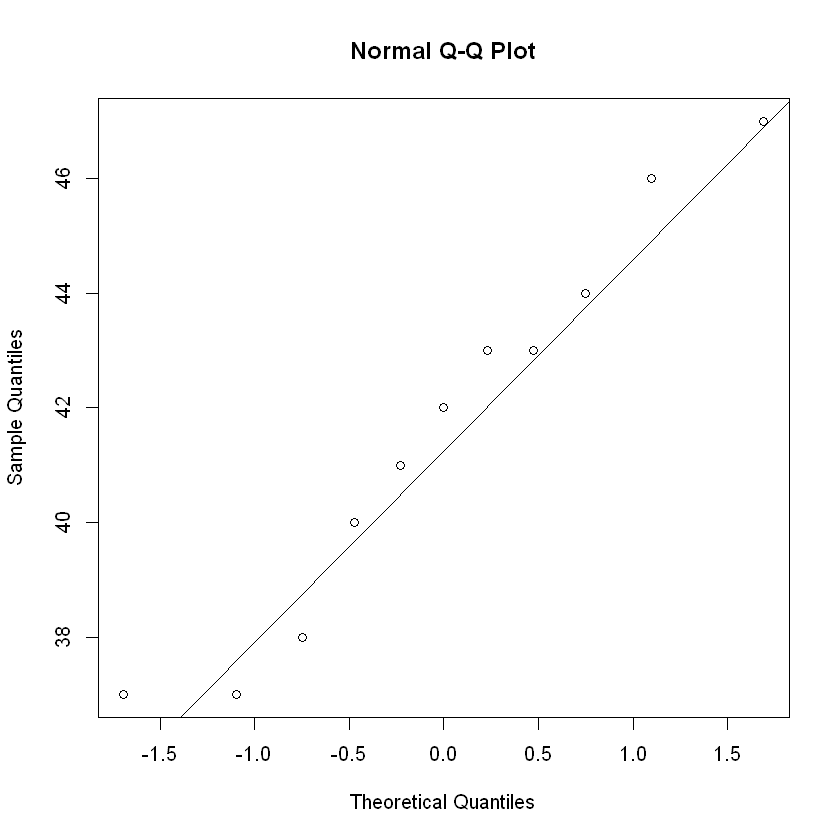

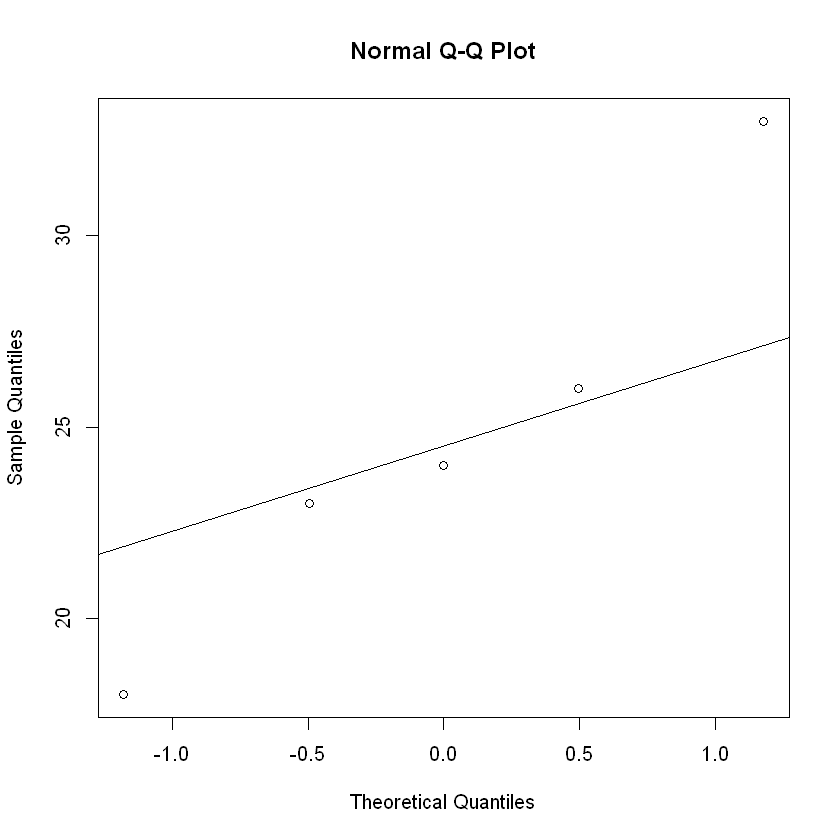

In [4]:
qqnorm(femme_g1)
qqline(femme_g1)

qqnorm(femme_g2)
qqline(femme_g2)


Les quantiles des femmes du groupe 1 s’alignent bien avec les quantiles théoriques d’une
loi normale, en revanche, pour le groupe 2 c’est plus compliqué à vérifier du fait du faible
échantillonnage (seulement 5 patientes). On remarque des diffcultés d’ajustement aux niveaux
des extrémités, ceci est probablement dû à la petite taille du jeu de données.

### 4.2 Égalité des variances = test de Fisher

#### Principe du test

On va vérifier l’égalité des variances entre les échantillons par [le test de Fisher-Snedecor](https://fr.wikipedia.org/wiki/Test_de_Fisher_d%27%C3%A9galit%C3%A9_de_deux_variances).
Ce test calcule une statistique appelée $F$ (comme Fisher) qui est le rapport entre la plus grande sur la plus petite des variances des deux échantillons. Si ce rapport est suffisamment supérieur à 1 avec un certain risque d'erreur $\alpha$ alors on considére les variances comme différentes

$$ F = \frac{\sigma^2_{\text{max}}}{\sigma^2_{\text{min}}}$$

avec $\sigma^2_{\text{max}}$ la variance de l'échantillon ayant la plus grande variance et $\sigma^2_{\text{min}}$ celle de celui avec la plus petite variance.

#### Hypothèses du test

Les hypothèses du test de Fisher sont les suivantes :

<div class="alert alert-warning" role="alert">

## Hypothèses

H0 : Les variances sont égales dans les deux échantillons  
H1 : Les variances sont différentes entre les deux échantillons

</div>

Il n'y a pas de condition d'application à vérifier pour réaliser le test.

#### Réalisation

Pour réaliser le test sur R, il faut utiliser la fonction `var.test()` (pour ***var**iance test* en anglais), cette fonction prend comme deux premiers arguments les deux échantillons à comparer.

*Réalisez le test avec les deux groupes*

In [5]:
var.test(femme_g1, femme_g2)


	F test to compare two variances

data:  femme_g1 and femme_g2
F = 0.39241, num df = 10, denom df = 4, p-value = 0.2099
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 0.04437067 1.75341717
sample estimates:
ratio of variances 
         0.3924089 


**Conclusion** :  

Au seuil 5%, p = 0,2099, on ne peut pas rejeter H0 quelque soit la valeur de $\alpha$.  
Toutes les conditions d'application sont donc validées pour réaliser le test de Student de comparaison de deux moyennes indépendantes.

## 5. Réalisation du test de Student

De la même façon que pour le test de comparaison à une moyenne théorique, le test peut s'effectuer de manière bilatérale ou unilatérale.
Ici, comme on veut savoir si les femmes du groupe 1 (qui n'ont pas eu d'acupuncture) ont des scores de dépression plus élevés que celles du groupe 2 (qui ont été traitées par de l'acupuncture), on va plutôt réaliser un test unilatéral, il faudra donc spécifier l'argument `alternative = "greater"`.

Les hypothèses de notre test sont donc :

<div class="alert alert-warning" role="alert">

## Hypothèses

H0 : Les moyennes sont égales dans les deux groupes.  
H1 : la moyenne du score de Hamilton du groupe 1 est supérieure à la moyenne du score de Hamilton du groupe 2.

</div>

Pour réaliser le test, on va à nouveau utiliser la fonction `t.test()` qui prend comme deux premiers arguments les deux échantillons, puis on spécifiera l'argument `alternative=`, enfin, étant donné qu'on a vérifié l'égalité des variances entre les échantillons on va spécifier l'argument logique `var.equal = TRUE`.

In [6]:
t.test(femme_g1, femme_g2, alternative = "greater", var.equal = TRUE)


	Two Sample t-test

data:  femme_g1 and femme_g2
t = 7.6134, df = 14, p-value = 1.213e-06
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 12.9414     Inf
sample estimates:
mean of x mean of y 
 41.63636  24.80000 


**Conclusion** :  

On observe p =  < alpha =  0.05, on rejette l’hypothèse H0 donc le score de Hamilton
du groupe 1 est supérieur au score de Hamilton du groupe 2. L’association traitement +
acupuncture est donc plus efficace que le traitement seul.

*Note : ici on a spécifié l'argument `var.equal = TRUE` (vrai) il peut prendre aussi la valeur `FALSE` (faux), cela signifierait que les variances des deux échantillons ne sont pas égales, dans ce cas-là c'est un autre test statistique qui est réalisé est le [test de Welch](https://fr.wikipedia.org/wiki/Test_t_de_Welch), c'est une adaptation du test de Student quand les variances ne sont pas égales*

<div class="alert alert-success">

## En résumé

Dans cette séance :

- Nous avons appris à effectuer un test de Student avec la fonction `t.test()`, en précisant deux arguments pour préciser les deux échantillons indépendants
- Nous avons appris les conditions d'application des tests de Student de comparaison de deux échantillons indépendants :
   - si $n_1 \geq 30$ et $n_2 \geq 30$, on peut directement procéder au test
   - si $n_1 < 30$ **ou** $n_2 < 30$ (ou bien les deux !), alors il faut :
       1. que les **deux échantillons** suivent une loi normale
       2. que les variances des deux échantillons soient égales
- Quand les variances sont égales, on précise `var.equal = TRUE` en argument de la fonction `t.test()`
- On peut aussi réaliser des tests unilatéraux quand on compare deux échantillons indépendants

</div>

## 6. Exercices

### Exercice d'application 

#### Exercice 1

L’activité diurétique d’un nouveau médicament et celle d’un produit X d’activité diurétique
connue sont comparées chez la souris. Vingt souris de même âge sont réparties en deux groupes
de 10. Un groupe reçoit le nouveau médicament et l’autre groupe reçoit le produit X. 

- **Question 1**. Parmi les trois méthodes indiquées ci-dessous, quelle est la méthode la plus appropriée pour constituer les deux groupes ? Justifier votre réponse.
    1. 1ère méthode : les 20 souris sont réparties par tirage au sort en 2 groupes de 10 souris.
    2. 2ème méthode : les 20 souris sont toutes placées dans une même cage, l’expérimentateur attrape les 10 premières souris qui se présentent à la sortie de la cage et les place dans une autre cage.
    3. 3ème méthode : toutes les souris sont pesées afin de constituer 2 groupes de poids le plus homogène possible. Ainsi, un groupe est constitué des 10 souris de poids le plus faible ; l’autre est constitué des 10 souris de poids le plus élevé.
- **Question 2**. Deux conceptions de protocole peuvent être envisagées. Le traitement connu peut être un placebo ou un traitement diurétique de référence. Discuter le choix de chacune de ces deux stratégies.
- **Question 3**. Une dose fixe de 20 mg du nouveau médicament ou du produit X est administrée à chaque animal. Les deux groupes de 10 souris sont placés dans des cages à métabolisme qui permettent une mesure facile du volume urinaire.  
  Les résultats sont contenus dans le fichier `exercice1_TD3.txt` qui est dans le dossier `data/` avec le chemin d'accès complet `data/exercice1_TD3.txt`.  
  La diurèse observée avec le nouveau médicament est-elle significativement supérieure à celle observée avec le produit X, au risque $\alpha = 5\%$, et au risque $\alpha = 1\%$ ?

**Question 1**

La méthode 1 est préférable car elle répartie aléatoirement els souris dans les 2 groupes ce qui évite tout biais comme par exemple avec la méthode 3 qui a un biais de poids et la méthode 1 un bias d'agilité. 

**Question 2**

- Le traitement connu peut être comparer à un placebo => Montre l'efficacité du traitement

- Le traitement connu peut être comparer à un traitement diurétique de référence => Montre que le nouveau traitement est plus efficace que le traitement de référence par exemple 

**Question 3**
La diurèse observée avec le nouveau médicament est-elle significativement supérieure à celle observée avec le produit X, au risque 5%, au risque 1% ?

Test de comparaison de deux échantillons indépendants

In [7]:
# Lecture des données
insurance = read.table("data/exercice1_TD3.txt",h=T)

head(insurance)

# description des données
summary(insurance$produit_x)
summary(insurance$nouveau_medicament)
dim(data)

# Effectif inférieur à 30 => vérification des condition d'application
shapiro.test(insurance$produit_x)
shapiro.test(insurance$nouveau_medicament)
var.test(insurance$nouveau_medicament,insurance$produit_x)

# H0 La diurèse observée avec le nouveau médicament est
# égale à celle observée avec le produit X
# H1 La diurèse observée avec le nouveau médicament 
# est supérieure à celle observée avec le produit X

t.test(insurance$nouveau_medicament,insurance$produit_x,alternative="greater"
       ,var.equal = T)

,produit_x,nouveau_medicament
,<dbl>,<dbl>
1,17.09903,23.54705
2,16.06864,23.40862
3,12.25383,23.55035
4,14.09870,17.86841
5,20.10046,21.40830
6,16.25313,16.51751


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  12.25   16.11   17.20   17.96   20.03   23.78 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  16.52   18.34   21.26   20.86   23.51   23.72 

NULL


	Shapiro-Wilk normality test

data:  insurance$produit_x
W = 0.96599, p-value = 0.8514



	Shapiro-Wilk normality test

data:  insurance$nouveau_medicament
W = 0.87496, p-value = 0.1141



	F test to compare two variances

data:  insurance$nouveau_medicament and insurance$produit_x
F = 0.56138, num df = 9, denom df = 9, p-value = 0.4027
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 0.139439 2.260115
sample estimates:
ratio of variances 
         0.5613806 



	Two Sample t-test

data:  insurance$nouveau_medicament and insurance$produit_x
t = 2.0101, df = 18, p-value = 0.02982
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 0.3989522       Inf
sample estimates:
mean of x mean of y 
 20.86216  17.95739 


### Exercices supplémentaires

#### Exercice 2

Pour cet exercice nous allons travailler un jeu de données contenant le nombre de morts par an par pays en fonction des différentes causes de mort sur plusieurs années.
Le fichier s'intitule `annual_number_of_deaths_by_cause.txt` et est situé dans le dossier `data/` avec le chemin d'accès complet `data/annual_number_of_deaths_by_cause.txt`.

1. Charger le jeu de données et décrivez le brièvement
   

In [8]:
deaths = read.table("data/annual_number_of_deaths_by_cause.txt", header = TRUE)

head(deaths)

,Entity,Code,Year,Number.of.executions,Meningitis.,Alzheimer.s.disease.and.other.dementias.,Parkinson.s.disease.,Nutritional.deficiencies.,Malaria.,Drowning.,⋯,Chronic.kidney.disease.,Poisonings.,Protein.energy.malnutrition.,Terrorism..deaths.,Road.injuries.,Chronic.respiratory.diseases.,Cirrhosis.and.other.chronic.liver.diseases.,Digestive.diseases.,Fire..heat..and.hot.substances.,Acute.hepatitis.
,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,Afghanistan,AFG,2007,15,2933,1402,450,2488,393,2127,⋯,4490,513,2439,1199,7425,7222,3346,6458,481,3437
2,Afghanistan,AFG,2008,17,2731,1424,455,2277,255,1973,⋯,4534,495,2231,1092,7355,7143,3316,6408,462,3005
3,Afghanistan,AFG,2009,0,2460,1449,460,2040,239,1852,⋯,4597,483,1998,1065,7290,7045,3291,6358,448,2663
4,Afghanistan,AFG,2011,2,2327,1508,473,1846,390,1775,⋯,4785,483,1805,1525,7432,6916,3318,6370,448,2365
5,Afghanistan,AFG,2012,14,2254,1544,482,1705,94,1716,⋯,4846,482,1667,3521,7494,6878,3353,6398,445,2264
6,Afghanistan,AFG,2013,2,2281,1581,491,1690,143,1777,⋯,4945,494,1651,3709,8054,6859,3413,6476,460,2204


2. Quelles sont les pays où il y a eu au moins une exécution ?  
   (indice : vous pouvez utiliser la fonction `table()` pour éviter d'afficher les pays où c'est arrivé plusieurs années).

In [9]:
table(deaths$Entity[deaths$Number.of.executions >= 1])


            Afghanistan                 Bahrain              Bangladesh 
                      8                       2                       9 
                Belarus                Botswana                    Chad 
                      7                       7                       1 
                  China                   Egypt       Equatorial_Guinea 
                      1                       7                       3 
               Ethiopia                  Gambia                   India 
                      1                       1                       3 
              Indonesia                    Iran                    Iraq 
                      5                      10                      10 
                  Japan                  Jordan                  Kuwait 
                      9                       2                       2 
                  Libya                Malaysia                Mongolia 
                      4                       5   

3. Quelles sont les années où il y a eu au moins une exécution ?  
   (indice : vous pouvez à nouveau utiliser la fonction `table()`)

In [10]:
table(deaths$Year[deaths$Number.of.executions >= 1])


2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 
  23   24   17   21   18   21   20   21   22   20 

4. Représentez le nombre de noyades (`Drowning.`) aux Barbades (`"Barbados"`) chaque année.

In [11]:
x

x = deaths$Drowning.[deaths$Entity == "Barbados"]

length(x)

boxplot(x, main = "Nombre de Noyades aux Barbades")

ERROR: Error in eval(expr, envir, enclos): objet 'x' introuvable


5. Quelles sont la variance, la moyenne, l'intervalle de confiance à 98% de la moyenne, la médiane, et le premier et dernier décile du nombre de décès par hépatite aiguë (`Acute.hepatitis.`) au Kirghizistan (`Kyrgyzstan`) depuis 2004 ?

**Remarque** : Vous observerez certainement des données manquantes sur `NA` (pour ***N**ot **A**vailable* en anglais). R permet de garder une trace explicite de ces données. Si vos données en contiennent, vous pouvez les enlever avec la fonction de `na.omit()` en réassignant vos données par exemple `x_no_na` :
`x_no_na = na.omit(x)`

Rappel : pour calculer des quantiles différents des quartiles, vous pouvez utiliser la fonction `quantile()` qui prend comme premier argument l'échantillon et en deuxième argument le nombre inférieur ou égal à 1 qui correspond au quantile à calculer.

In [ ]:
# Compute year number fifteen years ago
x = deaths$Acute.hepatitis.[deaths$Year >= 2004 & deaths$Entity == "Kyrgyzstan"]

summary(x)

# Remove NAs
xx=na.omit(x)

var(xx)
mean(xx)
CI(xx,0.98)
median(xx)
quantile(xx,0.1)
quantile(xx,0.9)

6.Même question pour les années avant 2011 au Koweït (*Kuwait*).

In [ ]:
x = deaths$Acute.hepatitis.[deaths$Year <= 2010]
summary(x)
xx=na.omit(x)
var(xx)
mean(xx)
CI(xx,0.98)
median(xx)
quantile(xx,0.1)
quantile(xx,0.9)

7. Dans quel pays et en quelles années se trouvent le nombre minimum de morts par malnutrition (`Nutritional.deficiencies.`).

In [ ]:
summary(deaths$Nutritional.deficiencies.)

# Calcul du nombre minimum de morts par malnutrition 
m = min(na.omit(deaths$Nutritional.deficiencies.))
m

# Pays
x=deaths$Entity[deaths$Nutritional.deficiencies.==m]
table(x)
xx=na.omit(x)
unique(xx)

# Années
y=deaths$Year[deaths$Nutritional.deficiencies.==m]
yy=na.omit(y)
unique(yy)

8. Tester au seuil à $\alpha = 0.98$, si la moyenne du nombre de morts par le paludisme (`Malaria`) en Inde (`"India"`) est inférieur à 79713.

In [ ]:
# Test de comparaison à une moyenne théorique
# H0 m = mu
# H1 m < mu

x=deaths$Malaria.[deaths$Entity=="India"]

# n=30 => Student
length(x)


t.test(x, mu = 79713, alternative = "less")

#Conclusion au seuil 2%, on ne peut pas rejeter H0

9. Tester, au seuil $\alpha = 1\%$, si le nombre de morts par méningite (`Meningitis.`) au Mexique (`"Mexico"`) est différent de sa moyenne moins une fois et demie son écart type. 

In [ ]:
# créer le groupe
x=deaths$Meningitis.[deaths$Entity=="Mexico"]

#Description
summary(x)

# n = 30 = test de Student
n=length(x)
n

# Calcul de mu
xecart = mean(x)-1.5*sd(x)/sqrt(n)

# Student
t.test(x, mu = xecart)

# au seuil 1%, pas de différence significative

10. Même question, mais cette fois la moyenne moins 3 fois son écart type
   

In [ ]:
# créer le groupe
x=deaths$Meningitis.[deaths$Entity=="Mexico"]

#Description
summary(x)

# n = 30 = test de Student
n=length(x)
n

# Calcul de mu
xecart=mean(x)-1.5*sd(x)/sqrt(n)

# Student
t.test(x,mu=xecart)

# au seuil 1%, différence significative

#### Exercice 3

En utilisant le jeu de données de l'exercice précédent répondez aux questions suivantes.

1. Tester au seuil  $\alpha =0.02 \%$ si le nombre de morts par la tuberculose (`Tuberculosis.`) en Argentine (`"Argentina"`) est différent de celui en France.

In [ ]:
# Créer les groupes

A=deaths$Tuberculosis.[deaths$Entity=="Argentina"]
F=deaths$Tuberculosis.[deaths$Entity=="France"]

# Description
summary(A)
summary(F)
length(A)
length(F)

# NA et NF = 30 => Student pour données indépendantes

# HO : pas de différence du nombre de morts entre les deux pays
# H1 : différence du nombre de morts entre les deux pays

t.test(A,F)

# Au seuil 2%, pvalue < 0.02, on rejète H0, il existe
# bien une différence significative du le nombre de morts par tuberculose
# entre l'Argentine et la France

2. Calculer les 2 intervalles de confiance, au niveau de confiance 0.99, de ces moyennes, concluez.

In [ ]:
CI(A,0.99)
CI(F,0.99)

3. Tester si la moyenne du nombre de morts par maladie cardiovasculaire (`Cardiovascular.diseases.`) est différente entre l'Irlande (`"Ireland"`) et l'Angleterre (`"England"`), au seuil $\alpha = 4\%$.
 

In [ ]:
# Créer les groupes

I=deaths$Cardiovascular.diseases.[deaths$Entity=="Ireland"]
E=deaths$Cardiovascular.diseases.[deaths$Entity=="England"]

# Description
summary(I)
summary(E)
length(I)
length(E)

# NA et NF = 30 => Student pour données indépendantes

# HO : pas de différence du nombre de morts entre les deux pays
# H1 : différence du nombre de morts entre les deux pays

t.test(I,E)

# Au seuil 4%, pvalue < 0.04, on rejète H0, il existe
# bien une différence significative du le nombre de morts par maladies
# Cardiaques est significativement différent entre l'Angleterre et 
# l'Irelande 

4. Tester si la moyenne du nombre de morts par maladie cirrhose (`Cirrhosis.and.other.chronic.liver.diseases.`) est différente entre la France et l'Égypte (`"Egypt"`), au seuil $\alpha = 1\%$.


In [ ]:
# Créer les groupes

E=deaths$Cirrhosis.and.other.chronic.liver.diseases.[deaths$Entity=="Egypt"]
F=deaths$Cirrhosis.and.other.chronic.liver.diseases.[deaths$Entity=="France"]

# Description
summary(F)
summary(E)
length(F)
length(E)

# NA et NF = 30 => Student pour données indépendantes

# HO : pas de différence du nombre de morts entre les deux pays
# H1 : différence du nombre de morts entre les deux pays

t.test(F,E)

# Au seuil 1%, pvalue < 0.01, on rejète H0, il existe
# bien une différence significative du nombre de morts par 
# maladie cirrhose est différente entre la France et l'Égypte

5. Tester si la moyenne du nombre de morts liés au trouble maternel (`Maternal.disorders.`) en Italie (`"Italy"`) est inférieure à celui du Botswana (`"Botswana"`), au seuil $\alpha = 3\%$. 

In [ ]:
# Créer les groupes

B=deaths$Maternal.disorders.[deaths$Entity=="Botswana"]
I=deaths$Maternal.disorders.[deaths$Entity=="Italy"]

# Description
summary(B)
summary(I)
length(B)
length(I)

# NA et NF = 30 => Student pour données indépendantes

# HO : pas de différence du nombre de morts entre les deux pays
# H1 : nb mort Italy < nb mort Botswana

t.test(I, B, alternative = "less")

# Au seuil 3%, pvalue < 0.03, on rejète H0, il existe
# nombre de morts liés au trouble maternel  
# en Italie est significativement inférieure à celui du Botswana 

#### Exercice 4

Nous allons utiliser le jeu de données `insurance.txt` déjà utilisé dans le TD 3

Rappel des données :

Le fichier de données `insurance.txt`, que nous allons analyser, est constitué des données clients suivantes:

- `age` : âge du principal bénéficiaire
- `sex` : sexe de l'assureur, féminin, masculin
- `bmi` : indice de masse corporelle (***b**ody **m**ass **i**ndex* en anglais), permettant de comprendre le corps, les poids relativement élevés ou faibles par rapport à la taille, indice objectif du poids corporel (kg/m^2) utilisant le rapport taille/poids, idéalement 18,5 à 24,9
-  `children` : Nombre d'enfants couverts par l'assurance maladie / Nombre de personnes à charge
- `smoker` : fumeur (`"yes"`) ou non (`no`)
- `region` : zone de résidence du bénéficiaire aux États-Unis (`"northeast"` = Nord-Est ;  `"northwest"` = Nord-Ouest ; `"southeast"` = Sud-Est ; `"southwest"` = Sud-Ouest)
- `charges` : Frais médicaux individuels facturés par l'assurance maladie

1. Charger le jeu de données `insurance.txt` qui se trouve dans le dossier `data/` soit le chemin d'accès `data/insurance.txt`

In [ ]:
data=read.table("data/insurance.txt",h=T)

head(data)

2. Soit la variable `bmi`, calculer sa moyenne, sa variance, ainsi que son écart interquartile et l'intervalle de confiance de sa moyenne au niveau de confiance 0.98 pour les femmes entre 25 et 45 ans compris.

In [ ]:
C.I <- function(x,alpha){
    alpha <- 1-alpha
    mu = mean(x)
    sigma <- sd(x)
    n = length(x)
    CI_inf = mu - (qt(1 - alpha/2,n-1) * sigma/sqrt(n))
    CI_sup = mu + (qt(1 - alpha/2,n-1) * sigma/sqrt(n))
    CI = c(inf = CI_inf ,sup = CI_sup) 
    return(CI)
    
}

In [ ]:
# créer le groupe de données
x=insurance$bmi[insurance$sex=="female" & insurance$age >= 25 & insurance$age <= 45 ]

length(x)

mean(x)
var(x)
quantile(x,0.75)-quantile(x,0.25)

# n > 30 donc on peut calculer l'IC
C.I(x,0.98)

3. Calculer les effectifs croisés entre les régions et le sexe  
   (il faut utiliser la fonction `table()` en précisant les deux variables comme deux premiers arguments de la fonction)


In [ ]:
table(insurance$region,insurance$sex)

4. Calculer les effectifs croisés entre les individus ayant 3 enfants ou plus et la région d'habitation.


In [ ]:
table(insurance$children[insurance$children>=3], insurance$region[insurance$children>=3])

5. Tester au seuil de $\alpha = 2\%$ si les charges d'assurance des hommes sont supérieures en moyenne à celle des femmes.


In [ ]:
# Test de comparaison de deux échantillons indépendants

# Groupes 
H=insurance$charges[insurance$sex=="male"]
F=insurance$charges[insurance$sex=="female"]

# description
length(F)
length(H)

summary(H)
summary(F)

# H0 : les charges d'assurances sont égales entre les hommes et 
# les femmes
# H1 : les charges d'assurances sont supérieures pour les hommes
# par rapport aux femmes

t.test(H,F,alternative="greater")

# Conclusion : au seuil 2%, pvalue < 0.01 donc on rejète H0
#les charges d'assurances sont significativement supérieures 
# pour les hommes
# par rapport aux femmes


6. Calculer l'intervalle de confiance de la moyenne des charges d'assurance des hommes et celui des femmes au niveau de confiance 98% et concluez


In [ ]:
# les effectifs sont >= 30 donc aps de condition d'application
C.I(H,0.98)
C.I(F,0.98)

7. Tester si les charges d'assurance des habitants du Northwest sont différentes en moyenne de celle des habitants du Southwest, au seuil $\alpha = 5\%$.


In [ ]:
# Test de comparaison de deux échantillons indépendants

# Groupes 
N=insurance$charges[insurance$region=="northwest"]
S=insurance$charges[insurance$region=="southwest"]

# description
length(N)
length(S)

summary(N)
summary(S)

# H0 : les charges d'assurances sont égales entre le nord et le sud 
# les femmes
# H1 : les charges d'assurances sont différentes entre el nord et le sud

t.test(N,S)

# Conclusion : au seuil 5%, pvalue > 0.05 donc on ne peut pas rejeter H0
# il n'y a pas de différence significative au nieavu des charges entre N et S


8. Tester si les hommes fumeurs sont plus jeunes en moyenne que les non-fumeurs, au seuil $\alpha = 3\%$.


In [ ]:
# Test de comparaison de deux échantillons indépendants

# Groupes 
F=insurance$age[insurance$smoker=="yes" & insurance$sex=="male"]
NF=insurance$age[insurance$smoker=="no" & insurance$sex=="male"]

# description
length(F)
length(NF)

summary(NF)
summary(F)

# H0 : les hommes fumeurs et non fumeur ont en moyenne le même âge
# H1 : les fumeurs sont plus jeunes que les non fumeurs

t.test(F,NF,alternative="less")

# Conclusion : au seuil 3%, pvalue > 0.03 donc on ne peut pas rejeter 
# H0
# les fumeurs ne sont pas significativement plus jeunes que les non fumeurs

9. Calculer l'intervalle de confiance de la moyenne de l'âge des hommes chez les fumeur puis chez les non fumeur au niveau de confiance 0.97, concluez.


In [ ]:
# description
length(F)
length(NF)
# pas de condition car effectif >=30

C.I(F,0.97)
C.I(NF,0.97)

10. Tester si les femmes fumeuses sont plus âgées en moyenne que les non-fumeuses, au seuil $\alpha = 3\%$.


In [ ]:
# Test de comparaison de deux échantillons indépendants

# Groupes 
F=insurance$age[insurance$smoker=="yes" & insurance$sex=="female"]
NF=insurance$age[insurance$smoker=="no" & insurance$sex=="female"]

# description
length(F)
length(NF)

summary(NF)
summary(F)

# H0 : les femmes fumeuses et non fumeuses ont en moyenne le même âge
# H1 : chez les femmes, les fumeurs sont plus agées que les non fumeurs

t.test(F,NF,alternative="greater")

# Conclusion : au seuil 3%, pvalue > 0.03 donc on ne peut pas rejeter 
# H0
# les femmes fumeuses et non fumeuses ont en moyenne le même âge

11. Calculer l'intervalle de confiance de la moyenne de l'âge des femmes chez les fumeuses puis chez les non fumeuses au niveau de confiance 0.97, concluez.

In [ ]:
C.I(NF,0.97)
C.I(F,0.97)